In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor

1. Exploring the Dataset

In [2]:
df = pd.read_csv("Medical_insurance.csv")
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [3]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(2772, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB
None
               age          bmi     children       charges
count  2772.000000  2772.000000  2772.000000   2772.000000
mean     39.109668    30.701349     1.101732  13261.369959
std      14.081459     6.129449     1.214806  12151.768945
min      18.000000    15.960000     0.000000   1121.873900
25%      26.000000    26.220000     0.000000   4687.797000
50%      39.000000    30.447500     1.000000   9333.014350
75%      51.000000    34.770000     2.000000  16577

Data Cleaning

In [4]:
# Removing Missing Values
df = df.dropna()

# Remove duplicates if any
df = df.drop_duplicates()

Univariate Analysis

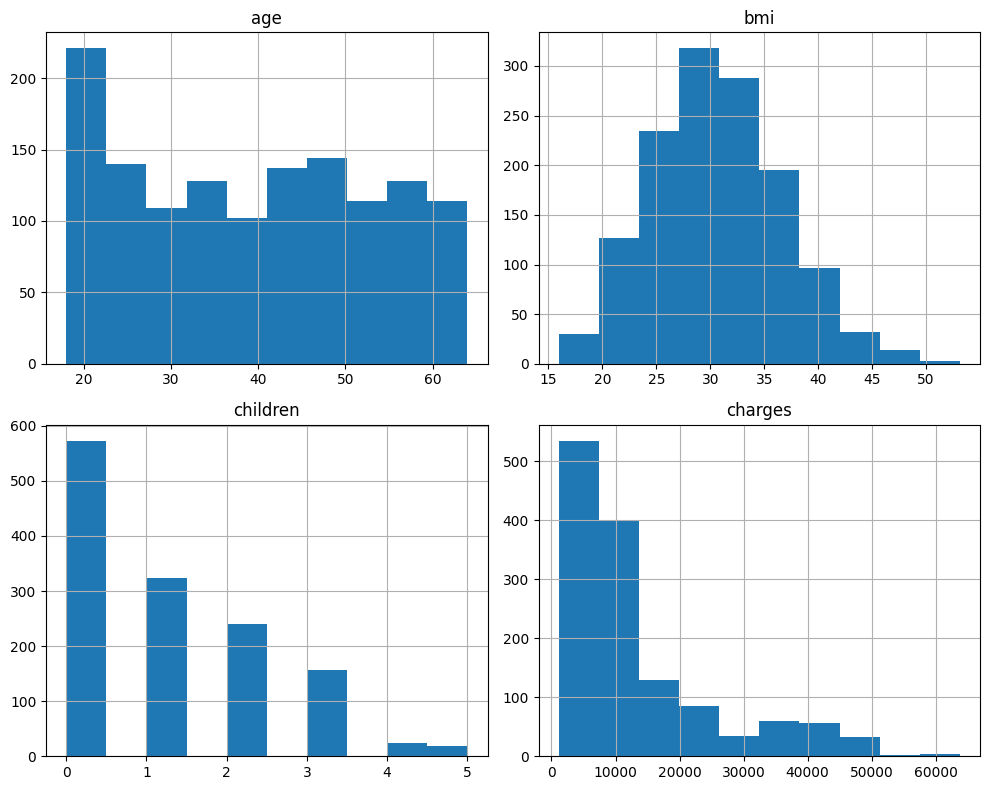

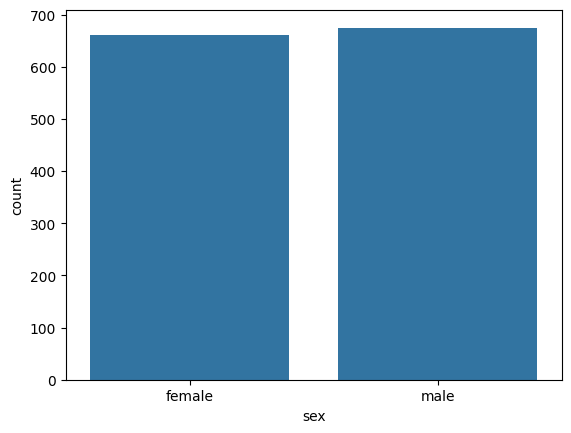

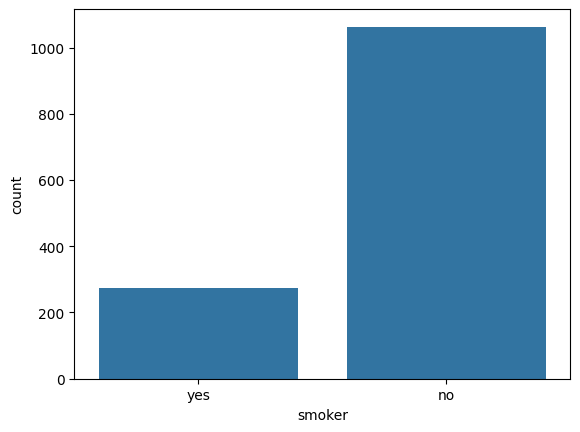

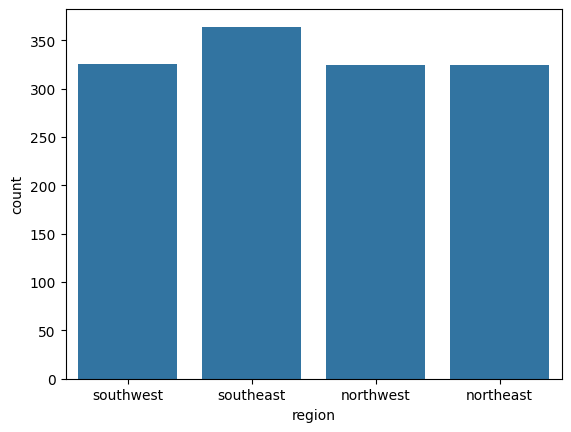

In [5]:
# Numerical distributions
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

# Categorical counts
sns.countplot(x='sex', data=df)
plt.show()

sns.countplot(x='smoker', data=df)
plt.show()

sns.countplot(x='region', data=df)
plt.show()

Bivariate Analysis

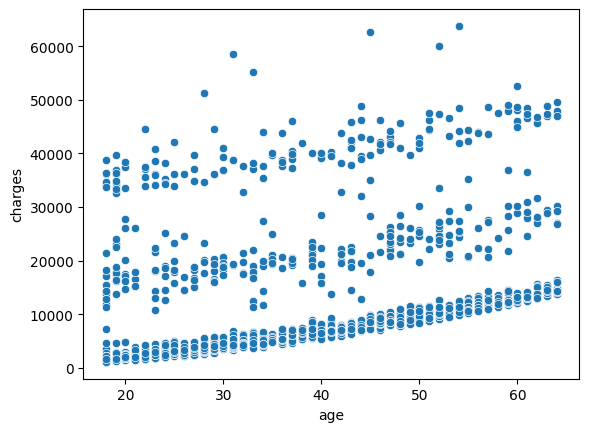

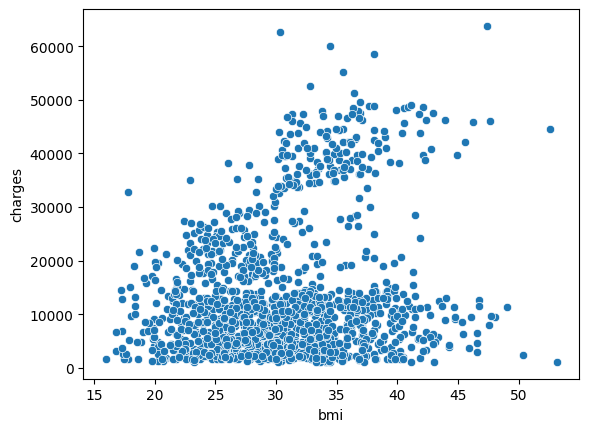

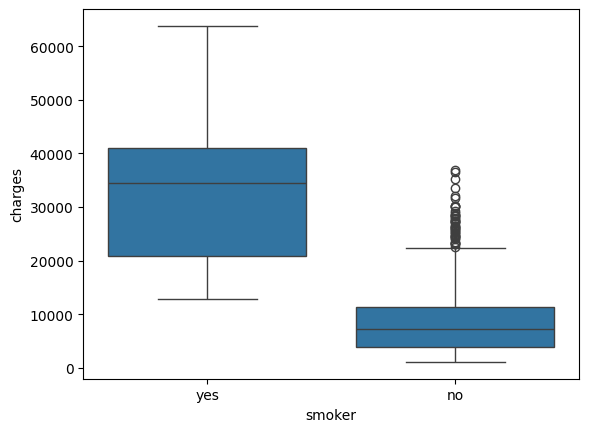

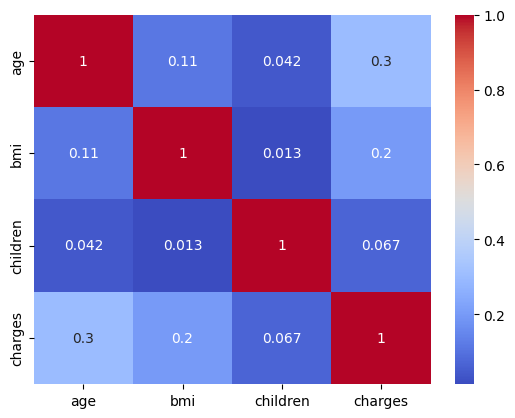

In [6]:
# Charges vs Age
sns.scatterplot(x='age', y='charges', data=df)
plt.show()

# Charges vs BMI
sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

# Smoker vs Charges
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Feature Engineering

In [7]:
# Create BMI Category
df['bmi_category'] = pd.cut(df['bmi'],
                           bins=[0, 18.5, 25, 30, 100],
                           labels=['underweight', 'normal', 'overweight', 'obese'])

# Create Age Groups
df['age_group'] = pd.cut(df['age'],
                        bins=[0, 18, 35, 50, 65],
                        labels=['teen', 'young_adult', 'adult', 'senior'])

# Interaction Feature
df['smoker_bmi'] = df['bmi'] * (df['smoker'] == 'yes').astype(int)

# One-Hot Encoding
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region', 'bmi_category', 'age_group'], drop_first=True)

Train-Test Split

In [8]:
X=df.drop('charges', axis=1)
y=df['charges']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature Scaling

In [10]:
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

Model Training

BaseLine Model

In [12]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

y_base = baseline.predict(X_test)

print("Baseline Model")
print("R2:", r2_score(y_test, y_base))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_base)))
print("MAE:", mean_absolute_error(y_test, y_base))

Baseline Model
R2: -0.008391982350864469
RMSE: 13612.426003009037
MAE: 9861.797880026175


Linear Regression

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

Linear Regression
R2: 0.8885792440693226
RMSE: 4524.8469103722455
MAE: 2784.3076475621115


Ridge and Lasso

In [14]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print("Ridge R2:", r2_score(y_test, ridge.predict(X_test)))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge.predict(X_test))))
print("Ridge MAE:", mean_absolute_error(y_test, ridge.predict(X_test)))
print("Lasso R2:", r2_score(y_test, lasso.predict(X_test)))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso.predict(X_test))))
print("Lasso MAE:", mean_absolute_error(y_test, lasso.predict(X_test)))

Ridge R2: 0.8893280023588941
Ridge RMSE: 4509.617576479789
Ridge MAE: 2781.12114098152
Lasso R2: 0.8885961155132619
Lasso RMSE: 4524.504318947245
Lasso MAE: 2784.3179484175016


Decision Tree

In [15]:
dt = DecisionTreeRegressor(max_depth=5)
dt.fit(X_train, y_train)

print("Decision Tree R2:", r2_score(y_test, dt.predict(X_test)))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, dt.predict(X_test))))
print("Decision Tree MAE:", mean_absolute_error(y_test, dt.predict(X_test)))

Decision Tree R2: 0.8912105527939065
Decision Tree RMSE: 4471.0983692822865
Decision Tree MAE: 2684.185949874536


Random Forest

In [16]:
rf = RandomForestRegressor(n_estimators=200,max_depth=20,min_samples_split=2, min_samples_leaf=1,random_state=42)
rf.fit(X_train, y_train)

print("Random Forest R2:", r2_score(y_test, rf.predict(X_test)))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf.predict(X_test))))
print("Random Forest MAE:", mean_absolute_error(y_test, rf.predict(X_test)))

Random Forest R2: 0.8801519228944269
Random Forest RMSE: 4692.846783330381
Random Forest MAE: 2656.4104092719813


Gradient Boosting

In [17]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05)
gb.fit(X_train, y_train)

print("Gradient Boosting R2:", r2_score(y_test, gb.predict(X_test)))
print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, gb.predict(X_test))))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, gb.predict(X_test)))

Gradient Boosting R2: 0.9006317748555028
Gradient Boosting RMSE: 4273.115250411881
Gradient Boosting MAE: 2463.78437135526


AdaBoost

In [20]:
from sklearn.ensemble import AdaBoostRegressor
ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1)
ada.fit(X_train, y_train)

print("AdaBoost R2:", r2_score(y_test, ada.predict(X_test)))
print("AdaBoost RMSE:", np.sqrt(mean_squared_error(y_test, ada.predict(X_test))))
print("AdaBoost MAE:", mean_absolute_error(y_test, ada.predict(X_test)))

AdaBoost R2: 0.8371242305239311
AdaBoost RMSE: 5470.777853887676
AdaBoost MAE: 4719.829158790192


XG Boost

In [21]:
xg= XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xg.fit(X_train, y_train)

print("XGBoost R2:", r2_score(y_test, xg.predict(X_test)))
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xg.predict(X_test))))
print("XGBoost MAE:", mean_absolute_error(y_test, xg.predict(X_test)))

XGBoost R2: 0.8865468377056578
XGBoost RMSE: 4565.928882081323
XGBoost MAE: 2490.0754956045066


Hyperparameter Tuning

Random Forest

In [22]:
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

print("Best RF Params:", rf_random.best_params_)
print("RF R2:", r2_score(y_test, best_rf.predict(X_test)))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test))))
print("RF MAE:", mean_absolute_error(y_test, best_rf.predict(X_test)))

Best RF Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 5}
RF R2: 0.9011556971199133
RF RMSE: 4261.8352912954115
RF MAE: 2431.130687023082


XG Boost

In [23]:
from xgboost import XGBRegressor

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    xgb_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)
best_xgb = xgb_random.best_estimator_

print("Best XGB Params:", xgb_random.best_params_)
print("XGB R2:", r2_score(y_test, best_xgb.predict(X_test)))
print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, best_xgb.predict(X_test))))
print("XGB MAE:", mean_absolute_error(y_test, best_xgb.predict(X_test)))

Best XGB Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
XGB R2: 0.8941292983839515
XGB RMSE: 4410.712349069561
XGB MAE: 2643.2355174365084


Gradient Boosting

In [24]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

gb_random = RandomizedSearchCV(
    GradientBoostingRegressor(),
    gb_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gb_random.fit(X_train, y_train)
best_gb = gb_random.best_estimator_

print("Best GB Params:", gb_random.best_params_)
print("GB R2:", r2_score(y_test, best_gb.predict(X_test)))
print("GB RMSE:", np.sqrt(mean_squared_error(y_test, best_gb.predict(X_test))))
print("GB MAE:", mean_absolute_error(y_test, best_gb.predict(X_test)))

Best GB Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01}
GB R2: 0.8946238135873043
GB RMSE: 4400.3992158505525
GB MAE: 2626.98891474484


Cross-Validation

In [28]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_gb, X_train, y_train, cv=5, scoring='r2')

print("Gradient Boosting")
print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))

Gradient Boosting
Cross Validation R2 Scores: [0.80821765 0.8623162  0.83657861 0.85420543 0.84759276]
Mean CV R2: 0.8417821322583576
Std Dev: 0.018779780023813333


In [29]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='r2')

print("Random Forest")
print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))

Random Forest
Cross Validation R2 Scores: [0.80560693 0.86530618 0.83807947 0.85956661 0.85474104]
Mean CV R2: 0.8446600456499063
Std Dev: 0.02153390199150261


In [30]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='r2')


print("XGBoost")
print("Cross Validation R2 Scores:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))

XGBoost
Cross Validation R2 Scores: [0.8050155  0.86462217 0.83626131 0.85645074 0.85071065]
Mean CV R2: 0.8426120729182678
Std Dev: 0.020954112026220363


Stacking

In [31]:
from sklearn.ensemble import StackingRegressor

estimators = [
    ('rf', best_rf),
    ('gb', best_gb),
    ('xgb', best_xgb)
]

stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)

print("Stacking R2:", r2_score(y_test, stack_pred))
print("Stacking RMSE:", np.sqrt(mean_squared_error(y_test, stack_pred)))
print("Stacking MAE:", mean_absolute_error(y_test, stack_pred))

Stacking R2: 0.9017619664997842
Stacking RMSE: 4248.74503531776
Stacking MAE: 2449.452588432545


In [32]:
from sklearn.linear_model import Ridge

stack_model = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xgb)
    ],
    final_estimator=Ridge(alpha=10),
    passthrough=True
)

stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)
print("Stacking with Ridge R2:", r2_score(y_test, stack_pred))
print("Stacking with Ridge RMSE:", np.sqrt(mean_squared_error(y_test, stack_pred)))
print("Stacking with Ridge MAE:", mean_absolute_error(y_test, stack_pred))

Stacking with Ridge R2: 0.9047722715862898
Stacking with Ridge RMSE: 4183.141470339983
Stacking with Ridge MAE: 2419.774077657671


Saving the Best Model

In [36]:
import pickle

# Save the trained stacking model
with open("stacking_model.pkl", "wb") as f:
    pickle.dump(stack_model, f)

In [37]:
with open("model_columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)